In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

In [6]:
b = {}
for w in words[:]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        # print(ch1, ch2)

In [7]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [8]:
import torch

In [9]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [10]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

In [11]:
for w in words[:]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        N[idx1, idx2] += 1
        # print(ch1, ch2)

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

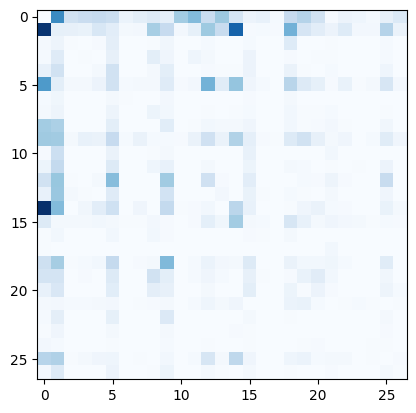

In [13]:
plt.imshow(N, cmap='Blues')

In [14]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [15]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [16]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p

tensor([0.7081, 0.3542, 0.1054])

In [17]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

In [18]:
P = N.float() + 1
P = P / P.sum(1, keepdim=True)
P[0]
P.sum(1, keepdim=True).shape

torch.Size([27, 1])

In [19]:
itos = {i:s for s, i in stoi.items()}

g = torch.Generator().manual_seed(2147483647)

for _ in range(10):
    idx: int = 0
    while True:
        p = P[idx]
        idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        print(itos[idx], end='')
        if idx == 0:
            print()
            break

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [20]:
likelihood = 0.0

for w in ['arima']:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        prob = P[idx1, idx2]
        log_prob = torch.log(prob)
        likelihood += log_prob
        print(f'{ch1}{ch2}: {prob:.4f} {log_prob:.4f}')
print(f'Likelihood: {likelihood:.4f}')
print(f'Negative Log-Likelihood: {-likelihood:.4f}')

.a: 0.1376 -1.9835
ar: 0.0963 -2.3405
ri: 0.2384 -1.4338
im: 0.0241 -3.7238
ma: 0.3885 -0.9454
a.: 0.1958 -1.6305
Likelihood: -12.0576
Negative Log-Likelihood: 12.0576


In [21]:
# create a training set of bigrams (x,y) where x is the first char and y is the second char
xs, ys = [], []
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        xs.append(idx1)
        ys.append(idx2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

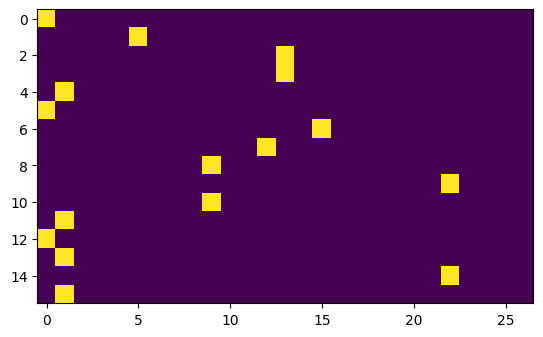

In [22]:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float()
plt.imshow(xenc)

In [23]:
w = torch.randn((27, 27), generator=g, requires_grad=True)
xenc @ w

tensor([[ 0.1861,  0.8415, -0.4016, -2.4100,  1.7720, -0.1270,  1.4172, -1.6930,
         -0.3540,  2.2246, -0.4667, -1.1209, -0.0265, -0.9626, -0.4413, -0.8477,
         -0.9468, -0.2705, -1.2589,  1.2130,  0.8729, -0.8185,  0.0348,  0.3700,
          0.0368, -0.0864, -0.2520],
        [-0.8960, -0.7261, -0.0284, -0.3716, -0.7032,  0.0650, -0.6850, -0.4411,
         -0.6407, -2.2924,  0.3534, -0.0294,  2.2914, -1.1258, -1.2025,  0.6428,
          0.7335, -0.9343, -0.5468, -0.4549,  0.4337, -0.9617, -1.1160, -0.0627,
         -0.0830,  0.6072,  0.2820],
        [ 2.0864,  0.5549,  0.4647, -0.6614, -0.2540,  0.0726, -0.0609,  0.8561,
          0.8630, -1.0330,  0.3259,  0.2486,  0.0210, -0.4981, -2.0558,  0.7752,
          1.1227,  0.3588, -1.1587, -0.5996,  3.6454, -0.3754, -1.4451, -0.2279,
          0.3164, -1.3394,  0.2314],
        [ 2.0864,  0.5549,  0.4647, -0.6614, -0.2540,  0.0726, -0.0609,  0.8561,
          0.8630, -1.0330,  0.3259,  0.2486,  0.0210, -0.4981, -2.0558,  0.7752

In [24]:
(xenc @ w)[3, 13]

tensor(-0.4981, grad_fn=<SelectBackward0>)

In [32]:
logits = xenc @ w
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(len(xs)), ys].log().mean()
loss

tensor(3.8569, grad_fn=<NegBackward0>)

In [26]:
loss = -probs[torch.arange(len(xs)), ys].log().mean()
loss

tensor(3.8660, grad_fn=<NegBackward0>)

In [30]:
w.grad = None # set to None before backward pass
loss.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [31]:
loss

tensor(3.8660, grad_fn=<NegBackward0>)

In [33]:
w.data += -0.1 * w.grad

TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'